# 04 - Validation & Sensitivity

**Phase 4 (Weeks 4–5)** of the Portuguese wildfire catastrophe loss model.

Goals:
- Backtest: hold out 2021-2025, refit on 2009-2020, compare simulated vs. actual
- Sensitivity analysis: vary NB mean (±10%), Lognormal σ (±10%), exposure growth (±5%/year)
- Climate scenario: model impact of +0.5°C / +1°C warming on frequency
- Document limitations: data sparsity, model assumptions, tail uncertainty

Hold-out window: **2021-2025** (confirmed in `wildfire_model.HOLDOUT_YEARS`). Within
this window, 2021 and 2023 were quiet years; 2022, 2024, and 2025 were bad years.
The 2017 and 2025 fire seasons bracket the extremes in the full record.

Domain validation (per PRD):
- Simulated average loss within the published industry range
- Extreme events captured: model predicts rare bad years (2025-level) at sensible frequency

## Imports

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

from pathlib import Path

sys.path.insert(0, "..")
from wildfire_model import (
    load_icnf_prdf_database, split_train_holdout, HOLDOUT_YEARS,
)
from monte_carlo import load_model_params, compute_risk_metrics, N_SCENARIOS, SEED
from validation import (
    training_simulation_params,
    compute_holdout_percentiles, plot_backtest_comparison,
    run_sensitivity_analysis, plot_sensitivity_tornado,
    apply_climate_scenario, run_climate_scenarios, plot_climate_scenarios,
    WARMING_ELASTICITY_PER_C,
)

PROCESSED_DIR  = Path("../data/processed")
MODELS_DIR     = Path("../models")
SIMULATION_DIR = Path("../simulation")

## Backtest

`split_train_holdout` is imported from `wildfire_model` (also used by
02_distribution_fitting.ipynb), not redefined here, so Phase 2 and Phase 4
can never disagree about which years are training vs. held-out. The
confirmed window (`docs/worklog.md`) is `TRAIN_YEARS = (2009, 2020)` /
`HOLDOUT_YEARS = (2021, 2025)` - fixed years, not a plain "last N years"
count.

In [2]:
# ── Data loading (shared by all three analyses below) ──────────────────────

# PRDF data for all years; train/holdout split mirrors Phase 2/3
prdf_all = load_icnf_prdf_database(start_year=2009, end_year=2025)
prdf_train, prdf_holdout = split_train_holdout(prdf_all)

# Loaded model parameters (Phase 2 production fit)
nb_params        = load_model_params("negative_binomial_frequency.json")
lognormal_params = load_model_params("lognormal_severity.json")
gpd_params       = load_model_params("pareto_tail.json")
euro_params      = load_model_params("severity_euro_equivalents.json")
eur_per_ha       = euro_params["central"]["eur_per_ha"]   # 2296.10 EUR/ha (central, 2025 prices)

# Tail probability and severity cap derived from training PRDF data
# (same derivation as Phase 3 production run)
tail_probability, cap_ha = training_simulation_params(prdf_train, gpd_params)
print(f"tail_probability = {tail_probability:.4f}   cap_ha = {cap_ha:,.0f} ha")
print(f"eur_per_ha = {eur_per_ha:.2f}   NB mean = {nb_params['mean']:.2f} fires/yr")

# ── Backtest ───────────────────────────────────────────────────────────────

# Phase 3 production simulation (200k scenarios, already computed)
sim_df           = pd.read_csv(SIMULATION_DIR / "monte_carlo_frailty_calibrated.csv")
simulated_losses = sim_df["annual_loss_eur"].values

# Holdout actual annual losses: PRDF burned area × central EUR/ha
holdout_annual_area = (
    prdf_holdout
    .assign(Year=prdf_holdout["Date"].dt.year)
    .groupby("Year")["Burned_Area_ha"]
    .sum()
)

holdout_results = compute_holdout_percentiles(simulated_losses, holdout_annual_area, eur_per_ha)
holdout_results

tail_probability = 0.1299   cap_ha = 1,260,995 ha
eur_per_ha = 2296.10   NB mean = 91.75 fires/yr


,year,actual_area_ha,actual_loss_eur,simulated_pct,simulated_return_period_yr
0,2021,20817.0,47799031.0,0.0,1.0
1,2022,101034.0,231984664.0,29.0,1.4
2,2023,27795.0,63820085.0,0.1,1.0
3,2024,132332.0,303848953.0,51.4,2.1
4,2025,264029.0,606238070.0,91.1,11.2


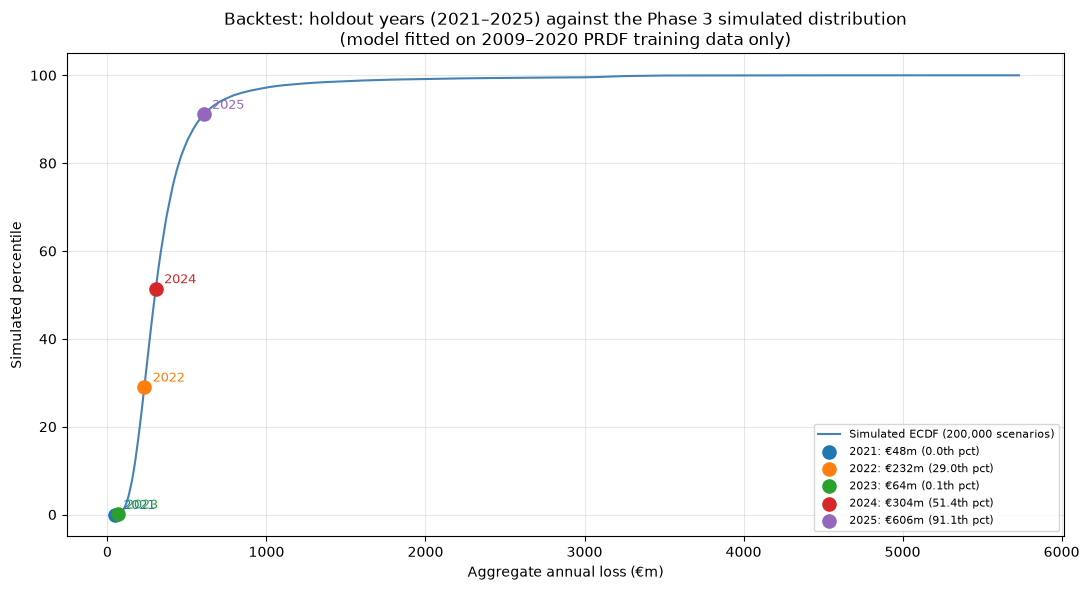

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_backtest_comparison(holdout_results, simulated_losses, ax=ax)
plt.tight_layout()
plt.savefig(MODELS_DIR / "backtest_holdout_chart.pdf")
plt.show()

## Sensitivity analysis

In [4]:
# Run ±10% shocks on NB mean, LN sigma, EUR/ha (50k scenarios each for speed)
sensitivity_df, base_var95 = run_sensitivity_analysis(
    nb_params, lognormal_params, gpd_params,
    tail_probability, cap_ha, eur_per_ha,
    n_scenarios=50_000,
)
print(f"Base VaR(95%) @ 50k scenarios: €{base_var95/1e6:.0f}m")
sensitivity_df

Base VaR(95%) @ 50k scenarios: €752m


,shock,var95_eur,delta_pct
0,NB mean −10%,684950962.0,-8.9
1,NB mean +10%,837172294.0,11.3
2,LN sigma −10%,711743120.0,-5.4
3,LN sigma +10%,815204445.0,8.4
4,EUR/ha −10%,676975957.0,-10.0
5,EUR/ha +10%,827415058.0,10.0


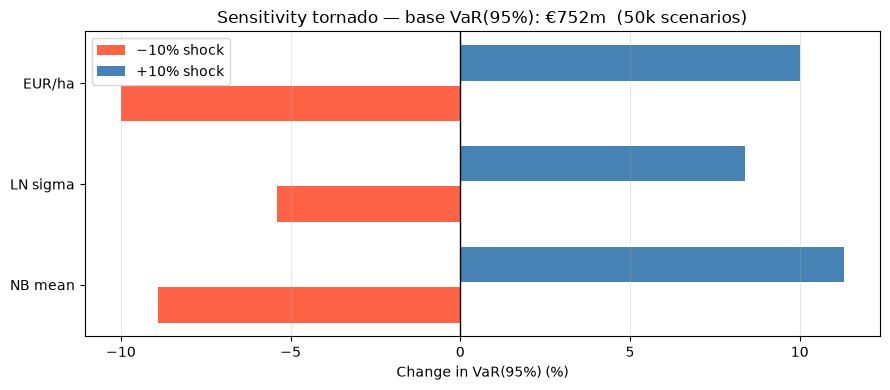

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_sensitivity_tornado(sensitivity_df, base_var95, ax=ax)
plt.tight_layout()
plt.savefig(MODELS_DIR / "sensitivity_tornado.pdf")
plt.show()

## Climate scenario

In [6]:
# Climate scenario: scale NB mean by the warming→frequency elasticity
# Elasticity source: median of 15-source distribution = 26.7%/°C
# Key papers: Turco 2018 NatCommun, El Garroussi 2024 npj (both: +40% at +1.5°C),
#             PESETA IV JRC Iberia (72-93% at RCP8.5/~3.5°C)
print(f"Warming elasticity: {WARMING_ELASTICITY_PER_C:.1%}/°C")
print()

# Show scenario NB means before running the full simulation
for w in [0.5, 1.0]:
    scenario_nb = apply_climate_scenario(nb_params, w)
    delta_pct = (scenario_nb["mean"] / nb_params["mean"] - 1) * 100
    print(f"+{w}°C: NB mean {nb_params['mean']:.1f} → {scenario_nb['mean']:.1f} fires/yr (+{delta_pct:.1f}%)")

# Run scenarios (100k scenarios each; baseline, +0.5°C, +1.0°C)
scenario_results = run_climate_scenarios(
    nb_params, lognormal_params, gpd_params,
    tail_probability, cap_ha, eur_per_ha,
    warming_levels=[0.5, 1.0],
    n_scenarios=100_000,
)
print()
for label, m in scenario_results.items():
    print(f"{label:18s}  VaR(95%)=€{m['VaR_95']/1e6:>6.0f}m  "
          f"ES(95%)=€{m['ES_95']/1e6:>6.0f}m  "
          f"mean=€{m['mean_loss']/1e6:>5.0f}m  "
          f"({m['nb_mean']:.1f} fires/yr)")

Warming elasticity: 26.7%/°C

+0.5°C: NB mean 91.7 → 104.0 fires/yr (+13.3%)
+1.0°C: NB mean 91.7 → 116.2 fires/yr (+26.7%)



Baseline (0°C)      VaR(95%)=€   760m  ES(95%)=€  1385m  mean=€  367m  (91.7 fires/yr)
+0.5°C              VaR(95%)=€   856m  ES(95%)=€  1503m  mean=€  417m  (104.0 fires/yr)
+1.0°C              VaR(95%)=€   941m  ES(95%)=€  1632m  mean=€  465m  (116.2 fires/yr)


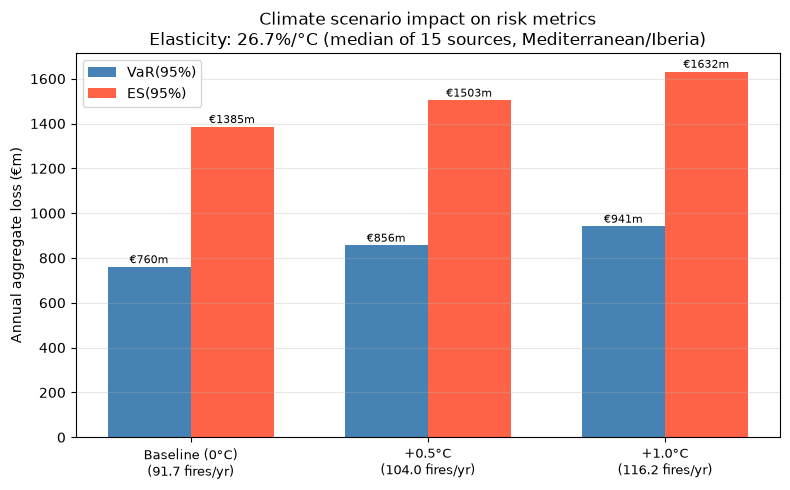

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_climate_scenarios(scenario_results, ax=ax)
plt.tight_layout()
plt.savefig(MODELS_DIR / "climate_scenarios.pdf")
plt.show()

## Run validation

All three analyses are wired up inline in their respective sections above.
The cells below are the final summary outputs.

In [8]:
# Summary table: backtest + climate scenario side-by-side
print("=" * 65)
print("PHASE 4 SUMMARY")
print("=" * 65)

print("\n--- Backtest (holdout 2021-2025 vs. Phase 3 simulation) ---")
print(holdout_results.to_string(index=False))

print("\n--- Sensitivity: VaR(95%) change under ±10% shocks ---")
print(sensitivity_df.to_string(index=False))

print("\n--- Climate scenarios ---")
for label, m in scenario_results.items():
    base_var = scenario_results["Baseline (0°C)"]["VaR_95"]
    delta = (m["VaR_95"] - base_var) / base_var * 100 if m["VaR_95"] != base_var else 0.0
    print(f"  {label:18s}  VaR(95%)=€{m['VaR_95']/1e6:.0f}m  "
          f"({delta:+.1f}% vs baseline)  ES(95%)=€{m['ES_95']/1e6:.0f}m")

PHASE 4 SUMMARY

--- Backtest (holdout 2021-2025 vs. Phase 3 simulation) ---
 year  actual_area_ha  actual_loss_eur  simulated_pct  simulated_return_period_yr
 2021         20817.0       47799031.0            0.0                         1.0
 2022        101034.0      231984664.0           29.0                         1.4
 2023         27795.0       63820085.0            0.1                         1.0
 2024        132332.0      303848953.0           51.4                         2.1
 2025        264029.0      606238070.0           91.1                        11.2

--- Sensitivity: VaR(95%) change under ±10% shocks ---
        shock   var95_eur  delta_pct
 NB mean −10% 684950962.0       -8.9
 NB mean +10% 837172294.0       11.3
LN sigma −10% 711743120.0       -5.4
LN sigma +10% 815204445.0        8.4
  EUR/ha −10% 676975957.0      -10.0
  EUR/ha +10% 827415058.0       10.0

--- Climate scenarios ---
  Baseline (0°C)      VaR(95%)=€760m  (+0.0% vs baseline)  ES(95%)=€1385m
  +0.5°C       

## Limitations and assumptions

- **Data sparsity**: 12 training years (2009–2020) of ICNF PRDF fire records.
  The GPD tail is fitted on 143 exceedances above the 87th-pct threshold
  (1,490 ha). Pre-2009 PRDF data exist but use different mapping methodology
  and are not included. The hold-out window (2021–2025, five years) is short
  for formal out-of-sample testing; the five holdout years span the full range
  from near-zero (2021: quiet) to extreme (2025: ~91st pct), which gives some
  coverage across the distribution even at small n.

- **Model assumptions**: fire-day events are treated as i.i.d. conditional on
  the annual NB count. Stationarity is assumed outside the climate scenario
  (no trend in frequency or severity over the training window is modelled).
  No spatial correlation, sub-regional granularity, or loss-amplification from
  concurrent regional events (out of scope per PRD).

- **Tail uncertainty**: GPD shape xi=0.786 (87th-pct threshold, 143 exceedances).
  xi > 0.5 implies infinite theoretical variance, stabilised by the 5× historical-
  max severity cap (1,260,995 ha). Bootstrap 95% CI for xi: [0.487, 1.053] — the
  upper bound implies even heavier tails than the central fit. A threshold
  sensitivity sweep (Phase 2) found xi ranges from 0.653 (92nd pct) to 0.849
  (90th pct); the 87th pct is the stable choice, not the only one.

- **Euro conversion**: central EUR/ha (2,296 EUR/ha, 2025 prices) is used
  throughout this notebook. The low/high scenarios (497/3,418 EUR/ha) produce
  proportional shifts in all EUR metrics and are not independently plotted here.

- **Climate scenario linearity**: the warming→frequency elasticity (26.7%/°C)
  is the median of 15 published Mediterranean/Iberian projections, but the
  distribution is wide (SD ≈ 21%/°C for the trimmed set). The actual climate–
  fire relationship is nonlinear, path-dependent, and modulated by vegetation
  feedbacks not captured in a simple NB mean scaling. The +0.5°C and +1.0°C
  results should be read as central-estimate order-of-magnitude impacts, not
  bounds. Severity (burned area per event) is held at the training-period
  distribution — a conservative assumption if fire behaviour also intensifies.